In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()
v = rdf.group_by("model").agg(pl.len()).sort("len", descending=True).collect()
for row in v.iter_rows(named=True):
    print(f"{row['model']}: {row['len']}")

/tmp/ipykernel_715473/2562833565.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()


rdst: 640
difference-mr-hydra: 640
polar-magnitude-mr-hydra: 640
scale-mr-hydra: 640
u-rstsf: 640
polar-angle-mr-hydra: 640
downsample-mr-hydra: 640
rank-mr-hydra: 640
rstsf: 640
mr-hydra: 640
stacker-v4-r1: 640
cumsum-mr-hydra: 640
catch22: 640
quant: 640
hivecotev2: 286
stacker-v4-r3: 23


In [3]:
df = (
    rdf
    .filter(pl.col("model") != "stacker-v4-r3")
    .filter(pl.col("model") != "difference-mr-hydra")
    .filter(pl.col("model") != "scale-mr-hydra")
    .filter(pl.col("model") != "cumsum-mr-hydra")
    .filter(pl.col("model") != "downsample-mr-hydra")
    .filter(pl.col("model") != "rank-mr-hydra")
    .filter(pl.col("model") != "polar-magnitude-mr-hydra")
    .filter(pl.col("model") != "polar-angle-mr-hydra")
    .filter(pl.col("model") != "catch22")

).collect(engine="streaming")
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""Trace""","""u-rstsf""",400,false,1.0
"""GesturePebbleZ2""","""stacker-v4-r1""",300,false,0.879747
"""SemgHandMovementCh2""","""mr-hydra""",300,false,0.771111
"""FaceFour""","""mr-hydra""",100,false,0.943182
"""UWaveGestureLibraryX""","""stacker-v4-r1""",300,false,0.872976
…,…,…,…,…
"""ScreenType""","""rstsf""",100,false,0.541333
"""ECG200""","""rdst""",300,false,0.9
"""SemgHandGenderCh2""","""stacker-v4-r1""",100,false,0.96


In [4]:
rdf.collect()['model'].unique()

model
str
"""hivecotev2"""
"""rstsf"""
"""scale-mr-hydra"""
"""rank-mr-hydra"""
"""stacker-v4-r1"""
…
"""u-rstsf"""
"""downsample-mr-hydra"""
"""mr-hydra"""


In [5]:
from aeon.visualisation import plot_critical_difference

In [6]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,u-rstsf,stacker-v4-r1,mr-hydra,quant,rdst,rstsf,hivecotev2
str,f64,f64,f64,f64,f64,f64,f64
"""Trace""",1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""GesturePebbleZ2""",0.787342,0.881013,0.872152,0.853165,0.877215,0.832911,0.898734
"""SemgHandMovementCh2""",0.835111,0.854667,0.757333,0.834222,0.699111,0.855556,0.877778
"""FaceFour""",0.945455,0.997727,0.947727,0.975,0.988636,0.995455,0.988636
"""UWaveGestureLibraryX""",0.841039,0.875098,0.871245,0.844556,0.855388,0.825349,0.855667
…,…,…,…,…,…,…,…
"""SemgHandGenderCh2""",0.934667,0.962333,0.956,0.951667,0.919667,0.972667,0.955
"""BirdChicken""",0.91,0.9,0.9,0.9,0.9,0.95,0.9
"""Wafer""",0.998248,0.99987,0.999676,1.0,1.0,0.99974,1.0


(<Figure size 600x260 with 1 Axes>, <Axes: >)

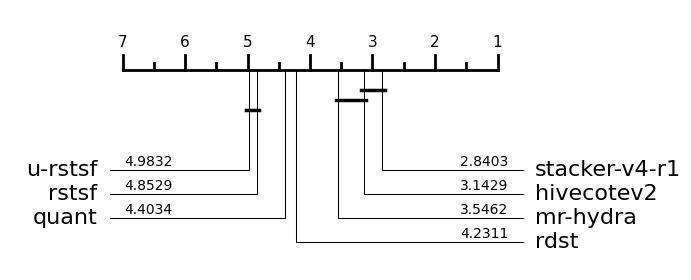

In [7]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [8]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [9]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,u-rstsf,stacker-v4-r1,mr-hydra,quant,rdst,rstsf,hivecotev2,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DiatomSizeReduction""",0.939216,0.964052,0.964052,0.915033,0.933987,0.929412,0.95915,16,306,4,345
"""DodgerLoopGame""",0.864567,0.864567,0.858268,0.867717,0.848819,0.870866,0.901575,17,127,2,288
"""InsectEPGSmallTrain""",1.0,1.0,1.0,1.0,0.991968,1.0,1.0,17,249,3,601
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BeetleFly""",0.87,0.94,0.9,0.81,0.95,0.9,0.925,20,20,2,512
…,…,…,…,…,…,…,…,…,…,…,…
"""NonInvasiveFetalECGThorax1""",0.917863,0.960407,0.959695,0.936285,0.929669,0.925496,0.948982,1800,1965,42,750
"""NonInvasiveFetalECGThorax2""",0.936387,0.96916,0.967735,0.948804,0.940153,0.938422,0.966412,1800,1965,42,750
"""PhalangesOutlinesCorrect""",0.841259,0.855711,0.846154,0.841492,0.807925,0.844988,0.837413,1800,858,2,80


61


(<Figure size 600x260 with 1 Axes>, <Axes: >)

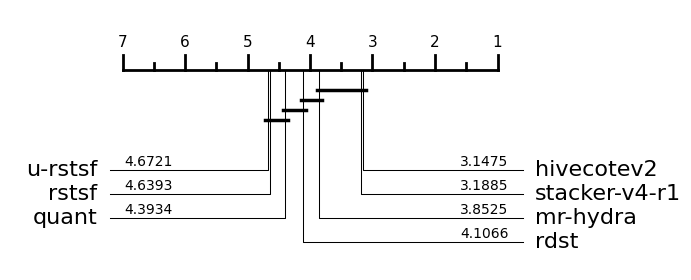

In [10]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

40


(<Figure size 600x260 with 1 Axes>, <Axes: >)

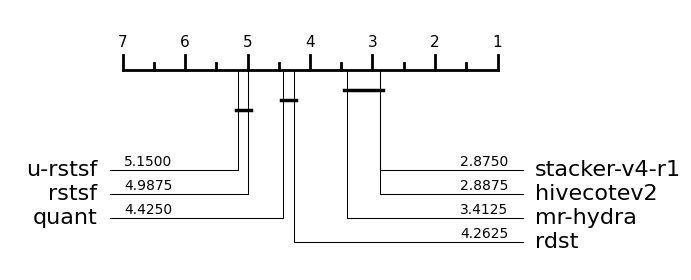

In [11]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

18


(<Figure size 600x260 with 1 Axes>, <Axes: >)

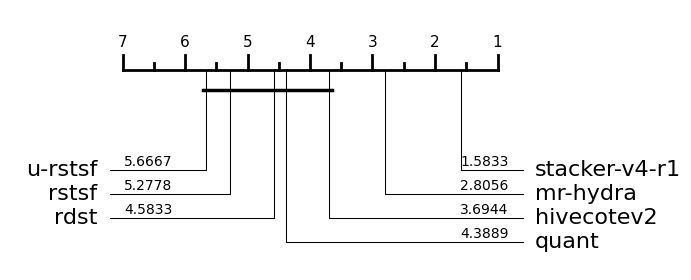

In [12]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [13]:
rdf.collect().pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).sort('downsample-mr-hydra')

dataset,polar-angle-mr-hydra,downsample-mr-hydra,scale-mr-hydra,polar-magnitude-mr-hydra,catch22,u-rstsf,stacker-v4-r1,cumsum-mr-hydra,mr-hydra,rank-mr-hydra,stacker-v4-r3,quant,rdst,rstsf,difference-mr-hydra,hivecotev2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Phoneme""",0.288502,0.327954,0.349895,0.354008,0.305802,0.38903,0.349895,0.269093,0.349895,0.34557,null,0.382278,0.337975,0.380907,0.369831,0.395042
"""InlineSkate""",0.436727,0.464364,0.496727,0.497455,0.434182,0.623636,0.586545,0.431273,0.497091,0.469818,null,0.586909,0.447273,0.601818,0.475273,0.532121
"""ScreenType""",0.488533,0.511467,0.529067,0.5392,0.501867,0.5504,0.546133,0.48,0.5472,0.495467,null,0.5328,0.5216,0.522133,0.5344,0.573333
"""MiddlePhalanxOutlineAgeGroup""",0.527273,0.515584,0.580519,0.544156,0.6,0.603896,0.580519,0.579221,0.576623,0.579221,null,0.61039,0.584416,0.597403,0.535065,0.571429
"""RefrigerationDevices""",0.589333,0.521067,0.528,0.524267,0.507733,0.5824,0.577067,0.506133,0.526933,0.5472,null,0.581867,0.5568,0.5904,0.538667,0.548
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GunPointOldVersusYoung""",0.996825,1.0,0.996825,1.0,1.0,1.0,1.0,0.989841,1.0,0.979683,null,1.0,1.0,1.0,1.0,1.0
"""GunPointMaleVersusFemale""",0.996835,1.0,1.0,1.0,0.990506,1.0,1.0,0.996835,1.0,0.982278,1.0,1.0,1.0,1.0,0.996835,1.0
"""InsectEPGRegularTrain""",1.0,1.0,1.0,1.0,0.999197,1.0,1.0,0.963052,1.0,0.9751,null,1.0,1.0,1.0,1.0,1.0
